# 04 — Sensitivity to Rashomon size K

**Purpose:** Test sensitivity to K (Rashomon size). Vary K ∈ {5, 10, 15, 20, 25, 30, 35, 40, 45, 50}, compute multiplicity and spatial metrics, plot stabilization curves.

## Imports and path setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import display_dataset_name, RAW_RESULTS, thesis_figure_dir, apply_thesis_plot_style
import matplotlib.pyplot as plt
apply_thesis_plot_style()

from analysis.knn_defaults import K_NN_BY_DATASET
from analysis.sensitivity import compute_k_sensitivity

FIG_DIR = thesis_figure_dir("nb04")

RESULTS_DIR = RAW_RESULTS
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

from analysis.cache import load_or_compute_df


## Loop over K and store results

In [2]:
K_LIST = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

SUPPORTED_DATASETS = ("compas", "german", "adult")

df_k = load_or_compute_df(
    CACHE_DIR / f"nb04_k_sensitivity_{CACHE_VERSION}.parquet",
    lambda: compute_k_sensitivity(
        RESULTS_DIR,
        datasets=SUPPORTED_DATASETS,
        K_list=K_LIST,
        k_nn_by_dataset=K_NN_BY_DATASET,
    ),
    force=FORCE_RECOMPUTE,
)

df_k.groupby(["dataset", "K"]).agg({
    "mean_variance": ["mean", "std"], "mean_conflict": ["mean", "std"],
    "moran_i": ["mean", "std"], "n_hh": "mean",
    "conflict_moran_i": ["mean", "std"], "conflict_n_hh": "mean",
}).round(4)


mean_variance         mean_conflict         moran_i          \
                    mean     std          mean     std    mean     std   
dataset K                                                                
adult   5         0.0006  0.0001        0.0102  0.0010  0.0306  0.0155   
        10        0.0009  0.0001        0.0132  0.0009  0.0457  0.0154   
        15        0.0010  0.0001        0.0146  0.0009  0.0572  0.0169   
        20        0.0012  0.0002        0.0157  0.0012  0.0657  0.0190   
        25        0.0014  0.0001        0.0172  0.0011  0.0749  0.0219   
        30        0.0016  0.0001        0.0186  0.0011  0.0861  0.0225   
        35        0.0018  0.0002        0.0203  0.0015  0.1037  0.0244   
        40        0.0022  0.0002        0.0224  0.0013  0.1265  0.0263   
        45        0.0024  0.0002        0.0237  0.0013  0.1475  0.0247   
        50        0.0025  0.0002        0.0247  0.0012  0.1667  0.0241   
compas  5         0.0005  0.0003        0.0180  0.0094  0.2048  0.0888   
        10        0.0008  0.0004        0.0261  0.0106  0.1851  0.0902   
        15        0.0010  0.0004        0.0286  0.0103  0.2025  0.0819   
        20        0.0011  0.0003        0.0326  0.0075  0.2043  0.0721   
        25        0.0013  0.0003        0.0354  0.0070  0.2100  0.0814   
        30        0.0015  0.0003        0.0386  0.0064  0.2075  0.0776   
        35        0.0016  0.0002        0.0412  0.0058  0.2044  0.0706   
        40        0.0018  0.0002        0.0432  0.0056  0.2055  0.0678   
        45        0.0019  0.0002        0.0449  0.0051  0.2124  0.0672   
        50        0.0020  0.0002        0.0460  0.0050  0.2254  0.0659   
german  5         0.0038  0.0019        0.0501  0.0199  0.0521  0.0344   
        10        0.0038  0.0018        0.0509  0.0191  0.0675  0.0365   
        15        0.0045  0.0019        0.0559  0.0204  0.0784  0.0428   
        20        0.0048  0.0021        0.0585  0.0219  0.0799  0.0427   
        25        0.0050  0.0021        0.0593  0.0219  0.0876  0.0388   
        30        0.0052  0.0016        0.0598  0.0176  0.0899  0.0382   
        35        0.0052  0.0014        0.0605  0.0156  0.0876  0.0373   
        40        0.0054  0.0013        0.0623  0.0126  0.0885  0.0381   
        45        0.0060  0.0013        0.0670  0.0100  0.0910  0.0397   
        50        0.0063  0.0013        0.0690  0.0075  0.0927  0.0414   

              n_hh conflict_moran_i         conflict_n_hh  
              mean             mean     std          mean  
dataset K                                                  
adult   5    141.8           0.0597  0.0085         190.5  
        10   281.4           0.0820  0.0088         346.5  
        15   399.6           0.0949  0.0089         440.0  
        20   508.6           0.1038  0.0109         529.6  
        25   630.3           0.1176  0.0132         624.5  
        30   744.4           0.1298  0.0124         707.6  
        35   939.1           0.1503  0.0155         825.6  
        40  1156.2           0.1709  0.0133         950.9  
        45  1263.2           0.1835  0.0127         877.6  
        50  1361.2           0.1929  0.0131         896.4  
compas  5    125.0           0.1031  0.0366          42.5  
        10   117.5           0.1322  0.0425          73.9  
        15   134.5           0.1426  0.0419          88.5  
        20   127.4           0.1593  0.0305         111.8  
        25   129.7           0.1667  0.0331         122.7  
        30   125.7           0.1743  0.0337         121.2  
        35   127.1           0.1798  0.0313         128.9  
        40   123.7           0.1867  0.0303         141.6  
        45   126.9           0.1920  0.0308         150.9  
        50   132.7           0.1946  0.0294         150.1  
german  5      2.4           0.0366  0.0297           0.9  
        10     3.9           0.0397  0.0271           0.5  
        15     4.6           0.0445  0.0247           1.0  
        

## Elbow / stabilization curves

Mean ± std bands over seeds for variance-based and conflict-based metrics across K.

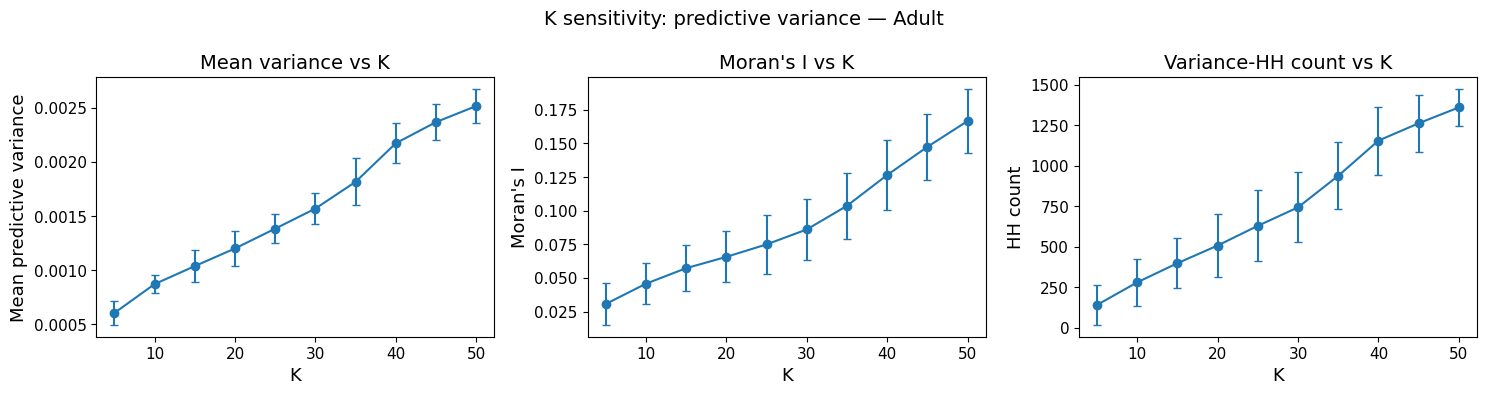

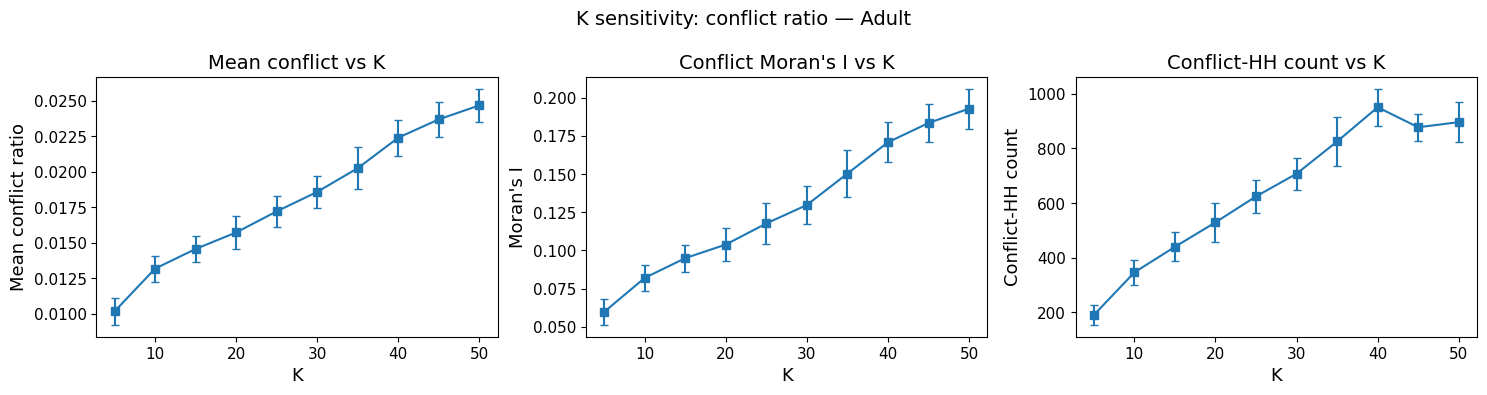

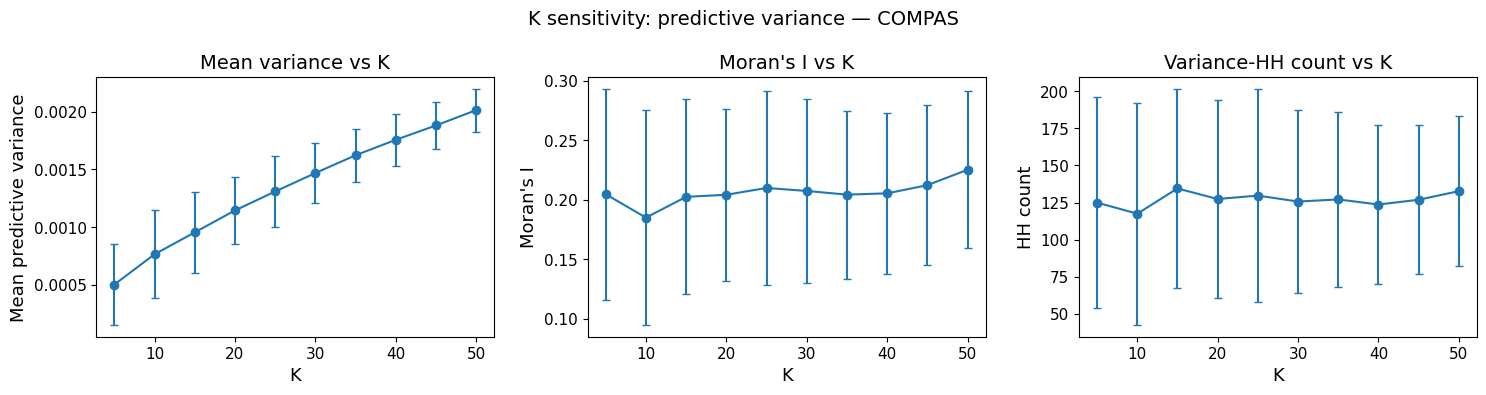

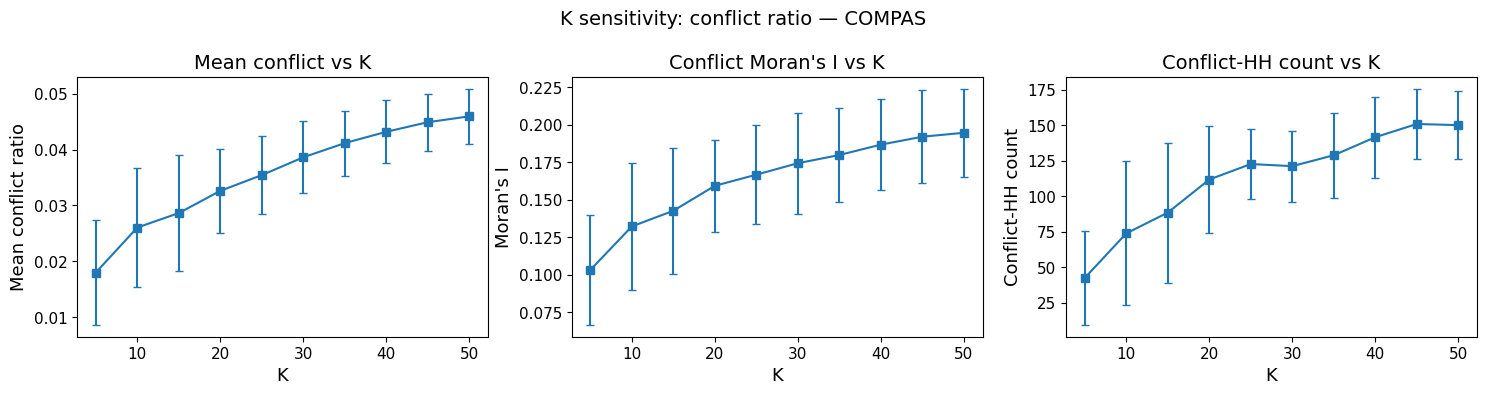

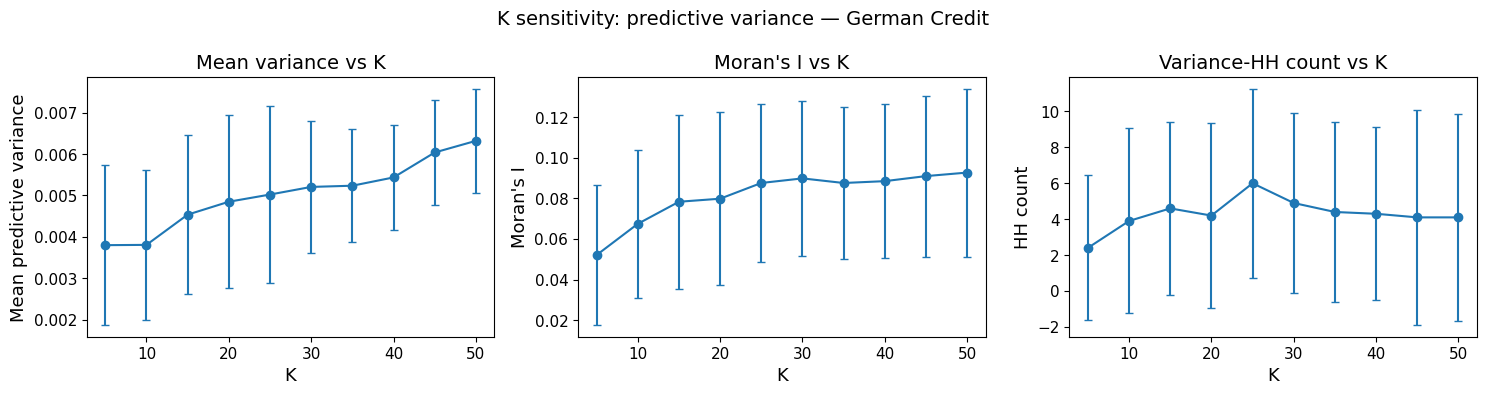

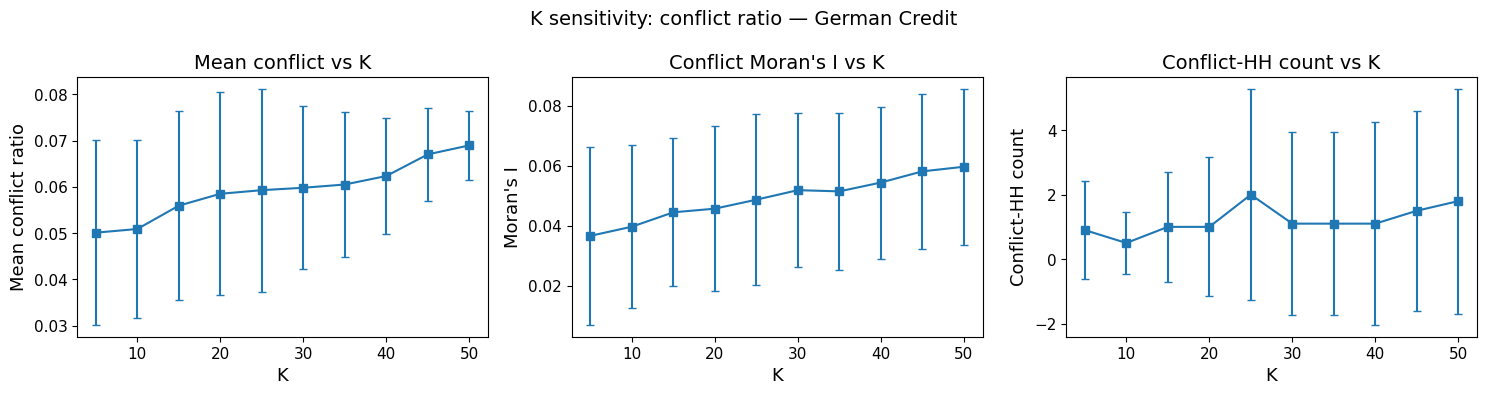

In [3]:
agg_k = df_k.groupby(["dataset", "K"]).agg(
    mean_variance_mean=("mean_variance", "mean"),
    mean_variance_std=("mean_variance", "std"),
    mean_conflict_mean=("mean_conflict", "mean"),
    mean_conflict_std=("mean_conflict", "std"),
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"),
    n_hh_std=("n_hh", "std"),
    conflict_moran_mean=("conflict_moran_i", "mean"),
    conflict_moran_std=("conflict_moran_i", "std"),
    conflict_n_hh_mean=("conflict_n_hh", "mean"),
    conflict_n_hh_std=("conflict_n_hh", "std"),
).reset_index()

for ds_name, ds_agg in agg_k.groupby("dataset"):
    d = ds_agg.sort_values("K")

    # ------------------------------------------------------------------
    # Predictive-variance K sensitivity
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].errorbar(
        d["K"], d["mean_variance_mean"],
        yerr=d["mean_variance_std"],
        marker="o", capsize=3
    )
    axes[0].set_xlabel("K")
    axes[0].set_ylabel("Mean predictive variance")
    axes[0].set_title("Mean variance vs K")

    axes[1].errorbar(
        d["K"], d["moran_mean"],
        yerr=d["moran_std"],
        marker="o", capsize=3
    )
    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Moran's I")
    axes[1].set_title("Moran's I vs K")

    axes[2].errorbar(
        d["K"], d["n_hh_mean"],
        yerr=d["n_hh_std"],
        marker="o", capsize=3
    )
    axes[2].set_xlabel("K")
    axes[2].set_ylabel("HH count")
    axes[2].set_title("Variance-HH count vs K")

    fig.suptitle(f"K sensitivity: predictive variance — {display_dataset_name(ds_name)}", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_K_variance_{ds_name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ------------------------------------------------------------------
    # Conflict-ratio K sensitivity
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].errorbar(
        d["K"], d["mean_conflict_mean"],
        yerr=d["mean_conflict_std"],
        marker="s", capsize=3
    )
    axes[0].set_xlabel("K")
    axes[0].set_ylabel("Mean conflict ratio")
    axes[0].set_title("Mean conflict vs K")

    axes[1].errorbar(
        d["K"], d["conflict_moran_mean"],
        yerr=d["conflict_moran_std"],
        marker="s", capsize=3
    )
    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Moran's I")
    axes[1].set_title("Conflict Moran's I vs K")

    axes[2].errorbar(
        d["K"], d["conflict_n_hh_mean"],
        yerr=d["conflict_n_hh_std"],
        marker="s", capsize=3
    )
    axes[2].set_xlabel("K")
    axes[2].set_ylabel("Conflict-HH count")
    axes[2].set_title("Conflict-HH count vs K")

    fig.suptitle(f"K sensitivity: conflict ratio — {display_dataset_name(ds_name)}", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_K_conflict_{ds_name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)